In [1]:
import pandas as pd
from autogluon.tabular import TabularPredictor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc
import shap

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')
df_train_merged = pd.read_csv('data/train_merged.csv')

In [3]:
TARGET = 'PitNextLap'

In [4]:
df_external = pd.read_csv("external/f1_strategy_dataset_v4.csv")

In [5]:
df_external.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [6]:
df_external["PitNextLap"].value_counts()

PitNextLap
0    75542
1    25829
Name: count, dtype: int64

In [7]:
predictor = TabularPredictor.load("ag_models5")

In [8]:
predictor_without_driver = TabularPredictor.load("ag_models6")

In [ ]:
df_test = df_external.head(10000)

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score


def evaluate_incremental_accuracy(
    predictor,
    df_test,
    target_col="PitNextLap",
    chunk_size=1000,
    plot=True,
    model=None,
):
    """Evaluates an AutoGluon predictor's accuracy incrementally in chunks of test samples.

    Parameters:
    -----------
    predictor : TabularPredictor
        The trained AutoGluon predictor instance.
    df_test : pd.DataFrame
        Test dataset containing features and the ground truth column.
    target_col : str, default='PitNextLap'
        Target column name in df_test.
    chunk_size : int, default=1000
        Number of test samples per step chunk.
    plot : bool, default=True
        Whether to display batch vs cumulative accuracy progression plot.
    model : str, optional
        Specific model name to evaluate. If None, evaluates the default (best) model.

    Returns:
    --------
    pd.DataFrame
        Table with 'samples_tested', 'batch_accuracy', and 'cumulative_accuracy'.
    """
    if target_col not in df_test.columns:
        raise ValueError(
            f"Target column '{target_col}' not found in the test DataFrame."
        )

    # 1. Predict probabilities
    probs = predictor.predict_proba(df_test, model=model)

    # 2. Derive predicted class labels
    if isinstance(probs, pd.DataFrame):
        y_pred = probs.idxmax(axis=1).values
    else:
        # Single Series/array of class 1 probabilities
        y_pred = (probs >= 0.5).astype(int).values

    y_true = df_test[target_col].values
    total_samples = len(df_test)
    metrics_data = []

    print(
        f"{'Samples Tested':<15} | {'Batch Accuracy':<15} | {'Cumulative Accuracy':<20}"
    )
    print("-" * 58)

    # 3. Iterate through data in chunks
    for i in range(chunk_size, total_samples + chunk_size, chunk_size):
        end_idx = min(i, total_samples)
        start_idx = max(0, end_idx - chunk_size)

        # Calculate metrics for current chunk batch
        batch_acc = accuracy_score(
            y_true[start_idx:end_idx], y_pred[start_idx:end_idx]
        )

        # Calculate running cumulative accuracy
        cum_acc = accuracy_score(y_true[:end_idx], y_pred[:end_idx])

        metrics_data.append({
            "samples_tested": end_idx,
            "batch_accuracy": batch_acc,
            "cumulative_accuracy": cum_acc,
        })

        print(
            f"1 to {end_idx:<9} | {batch_acc * 100:13.2f}% | {cum_acc * 100:18.2f}%"
        )

        if end_idx == total_samples:
            break

    df_metrics = pd.DataFrame(metrics_data)
    final_acc = accuracy_score(y_true, y_pred)
    print("-" * 58)
    print(
        f"Final Total Accuracy ({total_samples} samples): {final_acc * 100:.2f}%\n"
    )

    # 4. Render progression chart
    if plot:
        plt.figure(figsize=(10, 5))

        plt.plot(
            df_metrics["samples_tested"],
            df_metrics["cumulative_accuracy"] * 100,
            marker="o",
            linewidth=2.5,
            color="#1f77b4",
            label="Cumulative Accuracy",
        )

        plt.plot(
            df_metrics["samples_tested"],
            df_metrics["batch_accuracy"] * 100,
            linestyle="--",
            alpha=0.6,
            color="#ff7f0e",
            label=f"Batch Accuracy (per {chunk_size} samples)",
        )

        plt.axhline(
            y=final_acc * 100,
            color="red",
            linestyle=":",
            label=f"Overall Accuracy ({final_acc * 100:.2f}%)",
        )

        plt.title(
            f"Incremental Accuracy Progression for '{target_col}'",
            fontsize=14,
            fontweight="bold",
        )
        plt.xlabel("Number of Test Samples Evaluated", fontsize=12)
        plt.ylabel("Accuracy (%)", fontsize=12)
        plt.legend(loc="lower right")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    return df_metrics

In [12]:
import matplotlib.pyplot as plt
import pandas as pd


def evaluate_all_models_incremental(
    predictor, df_test, target_col="PitNextLap", chunk_size=1000
):
    """Runs evaluate_incremental_accuracy across all trained AutoGluon models and plots a combined comparison chart."""
    all_model_results = []
    model_list = predictor.model_names()
    best_model = predictor.model_best

    print(
        f"Evaluating {len(model_list)} models incrementally across {len(df_test)} test samples...\n"
    )

    # 1. Iterate over every model name
    for model_name in model_list:
        print(f"--> Processing Model: {model_name}")

        # Disable individual plotting during iteration
        df_res = evaluate_incremental_accuracy(
            predictor=predictor,
            df_test=df_test,
            target_col=target_col,
            chunk_size=chunk_size,
            plot=False,
            model=model_name,
        )
        df_res["model"] = model_name
        all_model_results.append(df_res)

    df_all_metrics = pd.concat(all_model_results, ignore_index=True)

    # 2. Plot combined cumulative accuracy curves
    plt.figure(figsize=(12, 6))

    for model_name in model_list:
        df_sub = df_all_metrics[df_all_metrics["model"] == model_name]

        # Highlight default best model with a thick black line
        if model_name == best_model:
            plt.plot(
                df_sub["samples_tested"],
                df_sub["cumulative_accuracy"] * 100,
                label=f"{model_name} (BEST)",
                linewidth=3,
                color="black",
                marker="o",
            )
        else:
            plt.plot(
                df_sub["samples_tested"],
                df_sub["cumulative_accuracy"] * 100,
                label=model_name,
                alpha=0.7,
                linestyle="--",
            )

    plt.title(
        f"Incremental Cumulative Accuracy Comparison across All Models ('{target_col}')",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Number of Test Samples Evaluated", fontsize=12)
    plt.ylabel("Cumulative Accuracy (%)", fontsize=12)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 3. Print final overall ranking table
    max_samples = df_all_metrics["samples_tested"].max()
    df_summary = (
        df_all_metrics[df_all_metrics["samples_tested"] == max_samples]
        .sort_values(by="cumulative_accuracy", ascending=False)[
            ["model", "cumulative_accuracy"]
        ]
        .reset_index(drop=True)
    )
    df_summary["cumulative_accuracy"] = (
        df_summary["cumulative_accuracy"] * 100
    ).round(2)
    df_summary.columns = ["Model Name", "Final Accuracy (%)"]

    print("\n" + "=" * 45)
    print("      FINAL ACCURACY RANKING SUMMARY")
    print("=" * 45)
    print(df_summary.to_string(index=False))

    return df_all_metrics




Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         99.22% |              99.22%
1 to 20000     |         99.46% |              99.34%
1 to 30000     |         97.93% |              98.87%
1 to 40000     |         97.14% |              98.44%
1 to 50000     |         97.15% |              98.18%
1 to 60000     |         98.13% |              98.17%
1 to 70000     |         98.14% |              98.17%
1 to 80000     |         97.69% |              98.11%
1 to 90000     |         96.88% |              97.97%
1 to 100000    |         97.18% |              97.89%
1 to 101371    |         97.13% |              97.86%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 97.86%



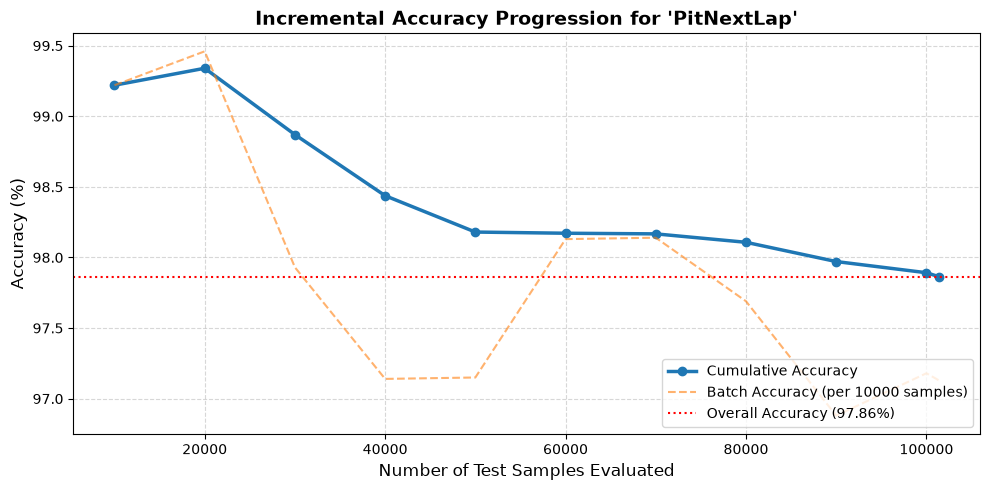

In [19]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)

Evaluating 5 models incrementally across 101371 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         98.84% |              98.84%
1 to 20000     |         99.05% |              98.95%
1 to 30000     |         97.41% |              98.43%
1 to 40000     |         95.65% |              97.74%
1 to 50000     |         95.98% |              97.39%
1 to 60000     |         96.80% |              97.29%
1 to 70000     |         97.00% |              97.25%
1 to 80000     |         96.66% |              97.17%
1 to 90000     |         95.53% |              96.99%
1 to 100000    |         96.12% |              96.90%
1 to 101371    |         96.16% |              96.88%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 96.88%

--> Processing Model: LightGBMLarge_BAG_L1
Samples Tested  | Batch Accuracy  | Cu

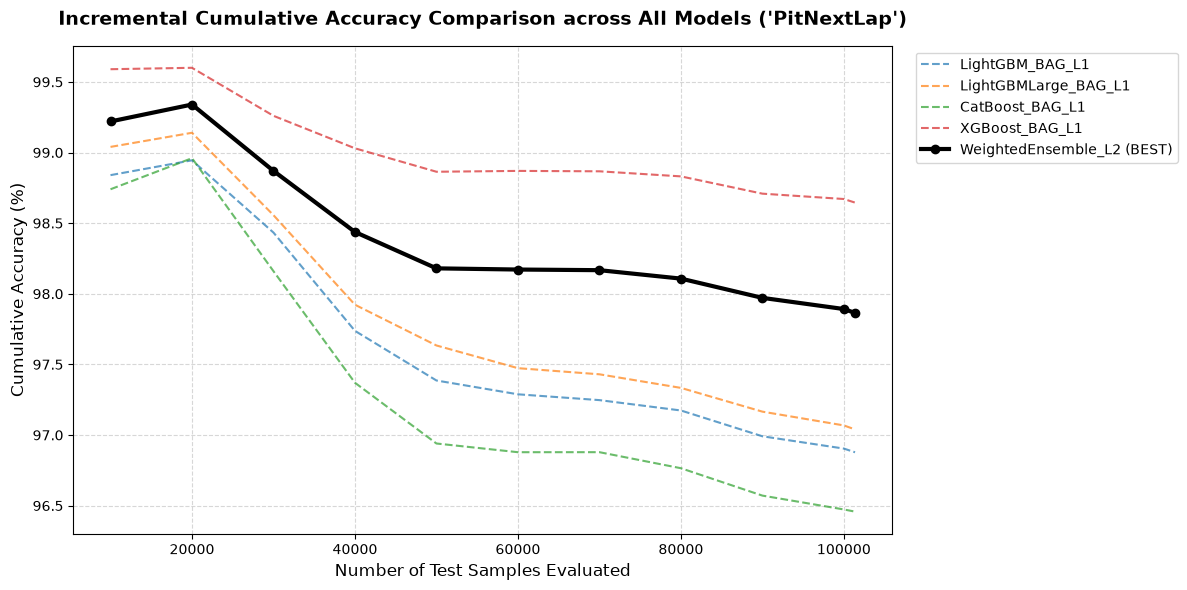


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
      XGBoost_BAG_L1               98.65
 WeightedEnsemble_L2               97.86
LightGBMLarge_BAG_L1               97.04
     LightGBM_BAG_L1               96.88
     CatBoost_BAG_L1               96.46


In [22]:
# Run across all models
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)

Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         93.00% |              93.00%
1 to 20000     |         92.97% |              92.98%
1 to 30000     |         92.63% |              92.87%
1 to 40000     |         93.11% |              92.93%
1 to 50000     |         92.74% |              92.89%
1 to 60000     |         93.20% |              92.94%
1 to 70000     |         93.29% |              92.99%
1 to 80000     |         93.44% |              93.05%
1 to 90000     |         93.26% |              93.07%
1 to 100000    |         93.16% |              93.08%
1 to 110000    |         93.47% |              93.12%
1 to 120000    |         92.80% |              93.09%
1 to 130000    |         92.58% |              93.05%
1 to 140000    |         92.98% |              93.05%
1 to 150000    |         93.24% |              93.06%
1 to 160000    |         93.05% |              93.06%
1 to 170000    |    

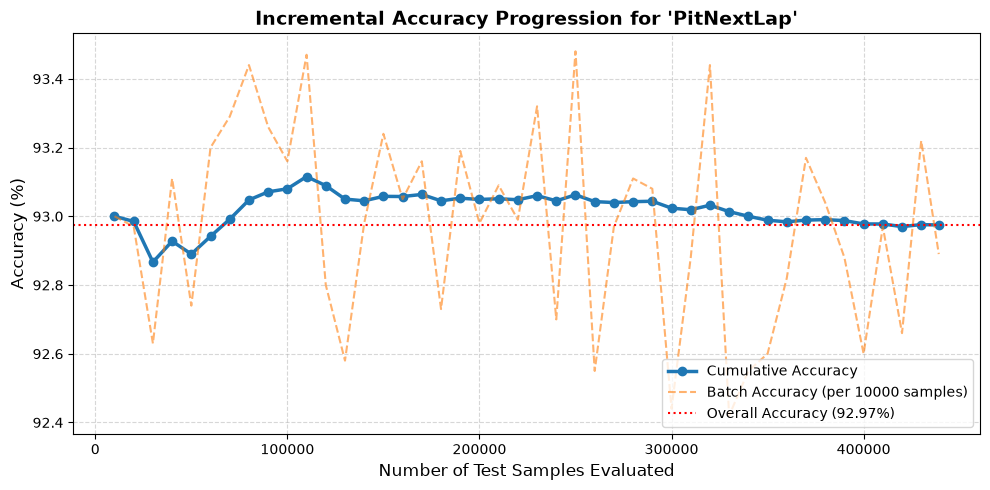

In [23]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

Evaluating 5 models incrementally across 439140 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         94.02% |              94.02%
1 to 20000     |         93.98% |              94.00%
1 to 30000     |         94.36% |              94.12%
1 to 40000     |         93.95% |              94.08%
1 to 50000     |         94.00% |              94.06%
1 to 60000     |         94.41% |              94.12%
1 to 70000     |         94.02% |              94.11%
1 to 80000     |         94.24% |              94.12%
1 to 90000     |         94.47% |              94.16%
1 to 100000    |         94.30% |              94.17%
1 to 110000    |         94.41% |              94.20%
1 to 120000    |         94.22% |              94.20%
1 to 130000    |         93.92% |              94.18%
1 to 140000    |         94.28% |              94.18%
1 to 150000    |         

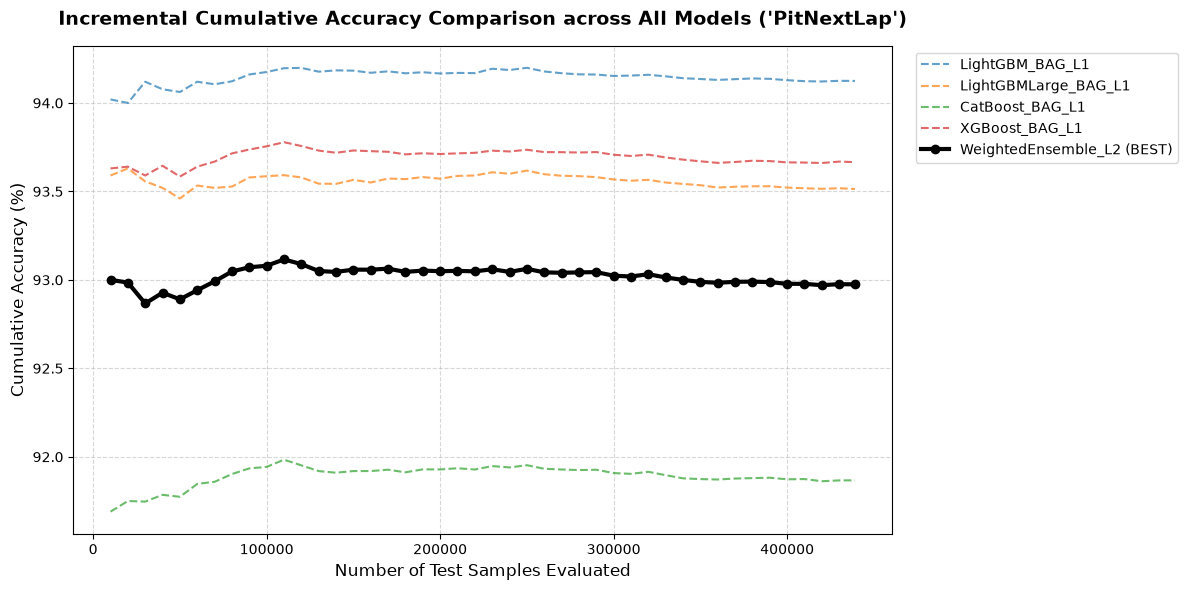


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
     LightGBM_BAG_L1               94.12
      XGBoost_BAG_L1               93.67
LightGBMLarge_BAG_L1               93.51
 WeightedEnsemble_L2               92.97
     CatBoost_BAG_L1               91.87


In [24]:
# Run across all models
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

# Without driver

Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         99.51% |              99.51%
1 to 20000     |         99.65% |              99.58%
1 to 30000     |         97.81% |              98.99%
1 to 40000     |         96.47% |              98.36%
1 to 50000     |         96.02% |              97.89%
1 to 60000     |         97.46% |              97.82%
1 to 70000     |         97.82% |              97.82%
1 to 80000     |         97.52% |              97.78%
1 to 90000     |         96.19% |              97.61%
1 to 100000    |         97.22% |              97.57%
1 to 101371    |         96.99% |              97.54%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 97.54%



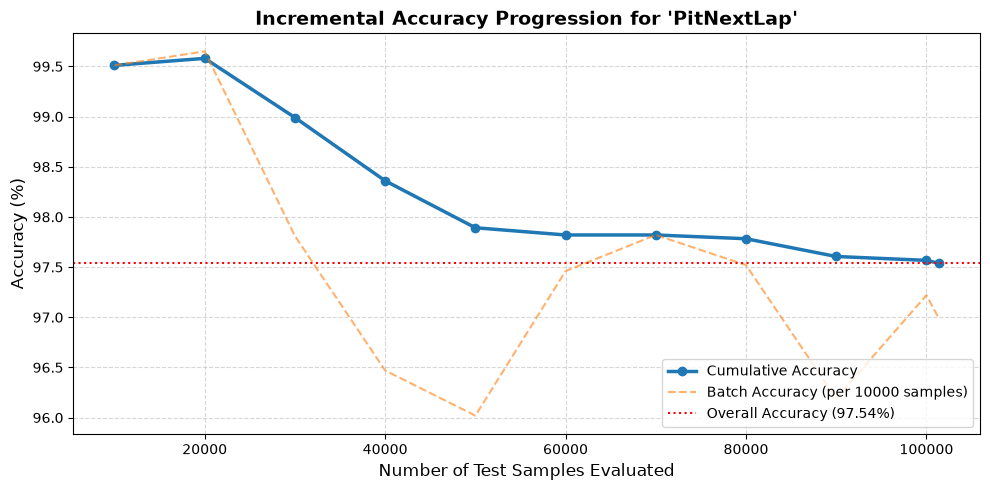

In [26]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor_without_driver, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)

Evaluating 5 models incrementally across 101371 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         99.61% |              99.61%
1 to 20000     |         99.72% |              99.67%
1 to 30000     |         98.17% |              99.17%
1 to 40000     |         97.08% |              98.65%
1 to 50000     |         96.92% |              98.30%
1 to 60000     |         97.92% |              98.24%
1 to 70000     |         98.41% |              98.26%
1 to 80000     |         98.16% |              98.25%
1 to 90000     |         96.94% |              98.10%
1 to 100000    |         97.63% |              98.06%
1 to 101371    |         97.58% |              98.04%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 98.04%

--> Processing Model: LightGBMLarge_BAG_L1
Samples Tested  | Batch Accuracy  | Cu

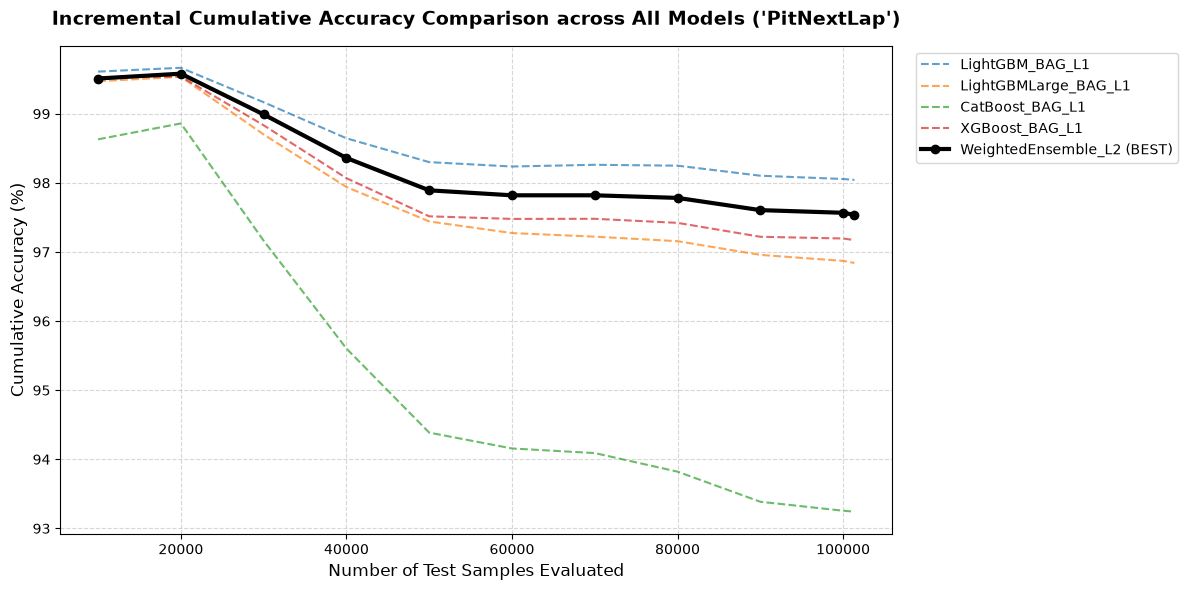


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
     LightGBM_BAG_L1               98.04
 WeightedEnsemble_L2               97.54
      XGBoost_BAG_L1               97.17
LightGBMLarge_BAG_L1               96.84
     CatBoost_BAG_L1               93.24


In [27]:
# Run across all models
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor_without_driver, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)

Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         93.47% |              93.47%
1 to 20000     |         93.29% |              93.38%
1 to 30000     |         93.20% |              93.32%
1 to 40000     |         93.56% |              93.38%
1 to 50000     |         93.37% |              93.38%
1 to 60000     |         93.76% |              93.44%
1 to 70000     |         93.51% |              93.45%
1 to 80000     |         93.78% |              93.49%
1 to 90000     |         93.65% |              93.51%
1 to 100000    |         93.31% |              93.49%
1 to 110000    |         93.97% |              93.53%
1 to 120000    |         93.20% |              93.51%
1 to 130000    |         93.26% |              93.49%
1 to 140000    |         93.38% |              93.48%
1 to 150000    |         93.63% |              93.49%
1 to 160000    |         93.38% |              93.48%
1 to 170000    |    

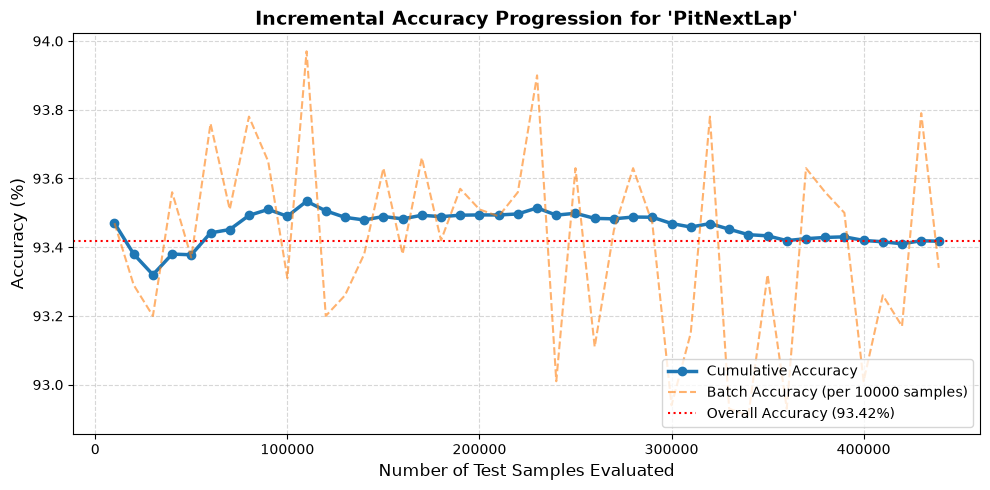

In [28]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor_without_driver, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

Evaluating 5 models incrementally across 439140 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         94.08% |              94.08%
1 to 20000     |         94.01% |              94.05%
1 to 30000     |         93.95% |              94.01%
1 to 40000     |         94.15% |              94.05%
1 to 50000     |         93.95% |              94.03%
1 to 60000     |         94.42% |              94.09%
1 to 70000     |         94.19% |              94.11%
1 to 80000     |         94.54% |              94.16%
1 to 90000     |         94.33% |              94.18%
1 to 100000    |         94.01% |              94.16%
1 to 110000    |         94.54% |              94.20%
1 to 120000    |         93.84% |              94.17%
1 to 130000    |         94.08% |              94.16%
1 to 140000    |         94.12% |              94.16%
1 to 150000    |         

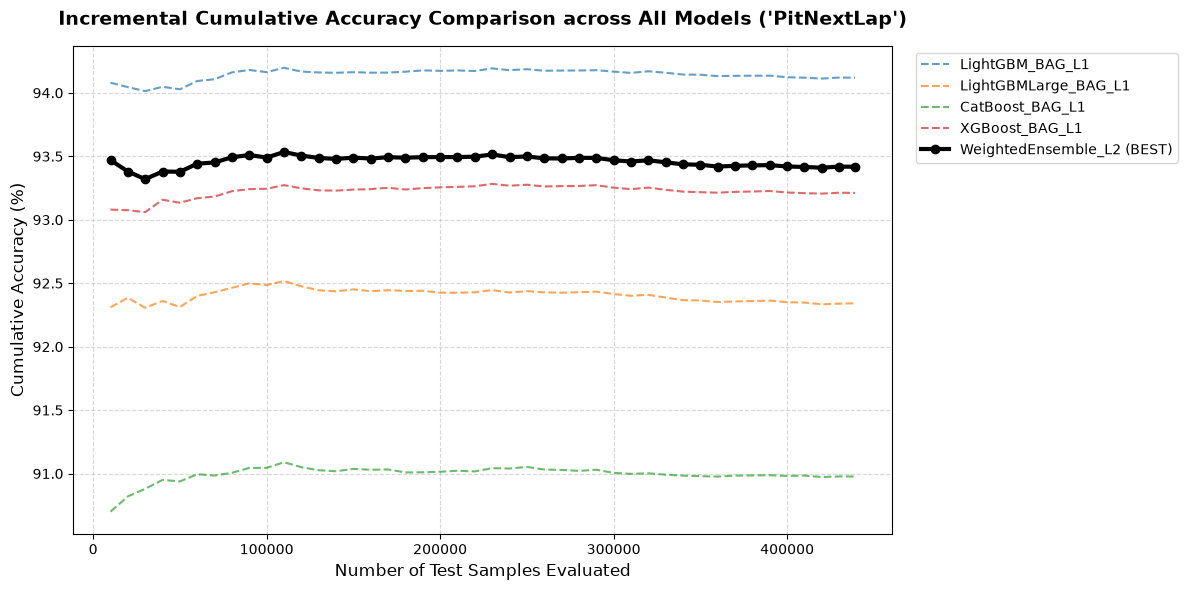


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
     LightGBM_BAG_L1               94.12
 WeightedEnsemble_L2               93.42
      XGBoost_BAG_L1               93.21
LightGBMLarge_BAG_L1               92.34
     CatBoost_BAG_L1               90.98


In [29]:
# Run across all models
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor_without_driver, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

In [31]:
# df_all_model_results

In [14]:
df_train["Driver"]="A"
df_external["Driver"]="A"


Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         91.67% |              91.67%
1 to 20000     |         91.77% |              91.72%
1 to 30000     |         91.75% |              91.73%
1 to 40000     |         91.81% |              91.75%
1 to 50000     |         91.57% |              91.71%
1 to 60000     |         92.12% |              91.78%
1 to 70000     |         91.76% |              91.78%
1 to 80000     |         92.12% |              91.82%
1 to 90000     |         92.11% |              91.85%
1 to 100000    |         91.85% |              91.85%
1 to 110000    |         92.40% |              91.90%
1 to 120000    |         91.50% |              91.87%
1 to 130000    |         91.50% |              91.84%
1 to 140000    |         92.01% |              91.85%
1 to 150000    |         92.04% |              91.87%
1 to 160000    |         91.87% |              91.87%
1 to 170000    |    

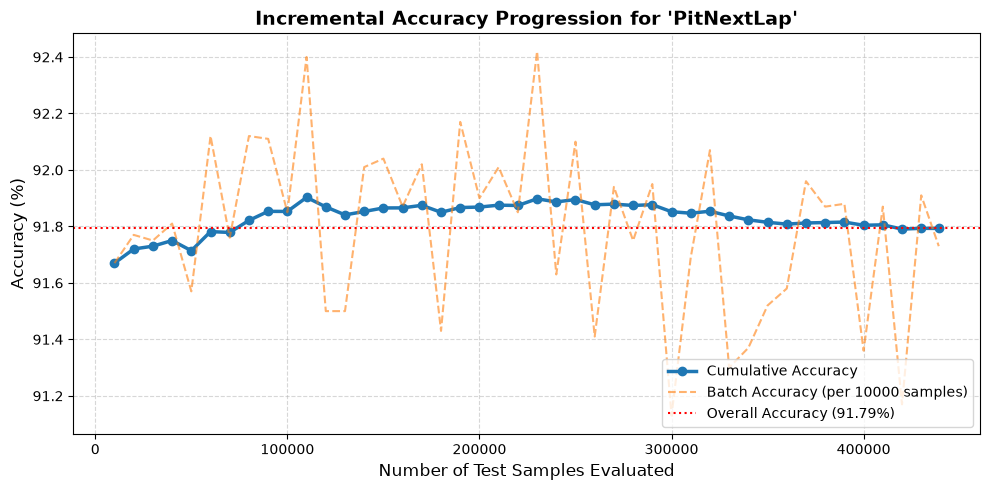

In [16]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         98.88% |              98.88%
1 to 20000     |         99.31% |              99.09%
1 to 30000     |         94.23% |              97.47%
1 to 40000     |         90.65% |              95.77%
1 to 50000     |         89.79% |              94.57%
1 to 60000     |         92.22% |              94.18%
1 to 70000     |         92.41% |              93.93%
1 to 80000     |         90.59% |              93.51%
1 to 90000     |         90.01% |              93.12%
1 to 100000    |         92.04% |              93.01%
1 to 101371    |         92.16% |              93.01%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 93.01%



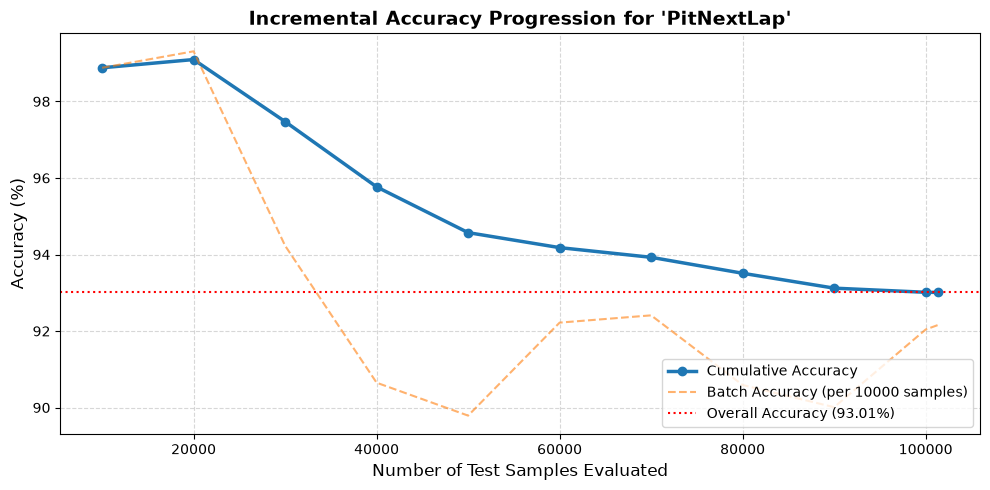

In [15]:
df_results = evaluate_incremental_accuracy(
    predictor=predictor, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)


Evaluating 5 models incrementally across 101371 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         99.61% |              99.61%
1 to 20000     |         99.72% |              99.67%
1 to 30000     |         98.17% |              99.17%
1 to 40000     |         97.08% |              98.65%
1 to 50000     |         96.92% |              98.30%
1 to 60000     |         97.92% |              98.24%
1 to 70000     |         98.41% |              98.26%
1 to 80000     |         98.16% |              98.25%
1 to 90000     |         96.94% |              98.10%
1 to 100000    |         97.63% |              98.06%
1 to 101371    |         97.58% |              98.04%
----------------------------------------------------------
Final Total Accuracy (101371 samples): 98.04%

--> Processing Model: LightGBMLarge_BAG_L1
Samples Tested  | Batch Accuracy  | Cu

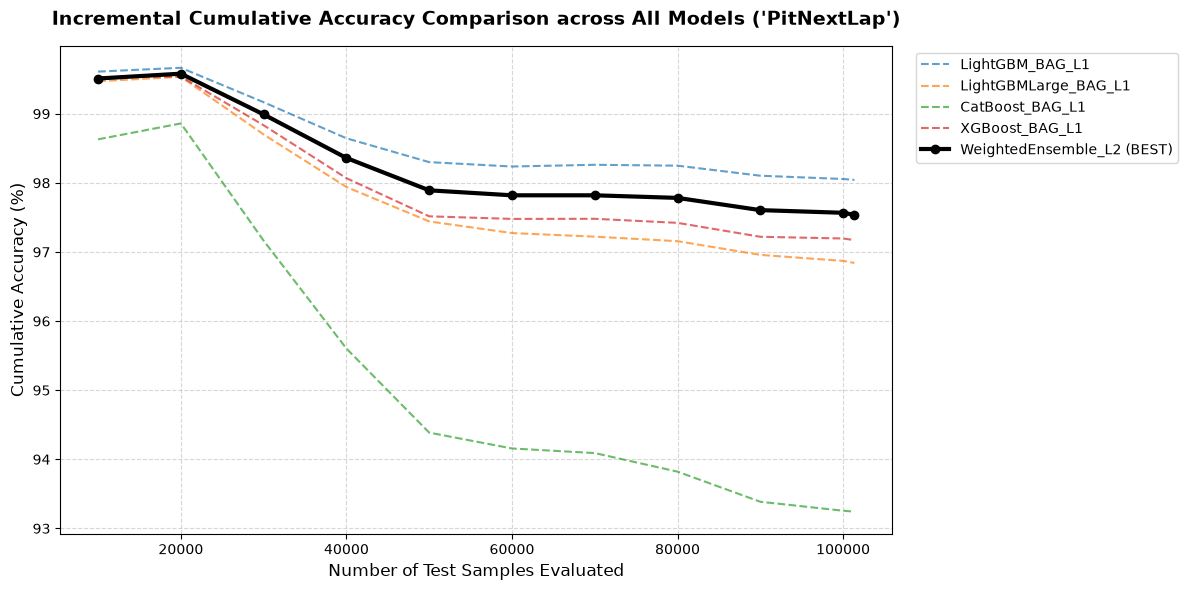


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
     LightGBM_BAG_L1               98.04
 WeightedEnsemble_L2               97.54
      XGBoost_BAG_L1               97.17
LightGBMLarge_BAG_L1               96.84
     CatBoost_BAG_L1               93.24


In [17]:
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor_without_driver, df_test=df_external, target_col="PitNextLap", chunk_size=10000
)

Evaluating 5 models incrementally across 439140 test samples...

--> Processing Model: LightGBM_BAG_L1
Samples Tested  | Batch Accuracy  | Cumulative Accuracy 
----------------------------------------------------------
1 to 10000     |         94.08% |              94.08%
1 to 20000     |         94.01% |              94.05%
1 to 30000     |         93.95% |              94.01%
1 to 40000     |         94.15% |              94.05%
1 to 50000     |         93.95% |              94.03%
1 to 60000     |         94.42% |              94.09%
1 to 70000     |         94.19% |              94.11%
1 to 80000     |         94.54% |              94.16%
1 to 90000     |         94.33% |              94.18%
1 to 100000    |         94.01% |              94.16%
1 to 110000    |         94.54% |              94.20%
1 to 120000    |         93.84% |              94.17%
1 to 130000    |         94.08% |              94.16%
1 to 140000    |         94.12% |              94.16%
1 to 150000    |         

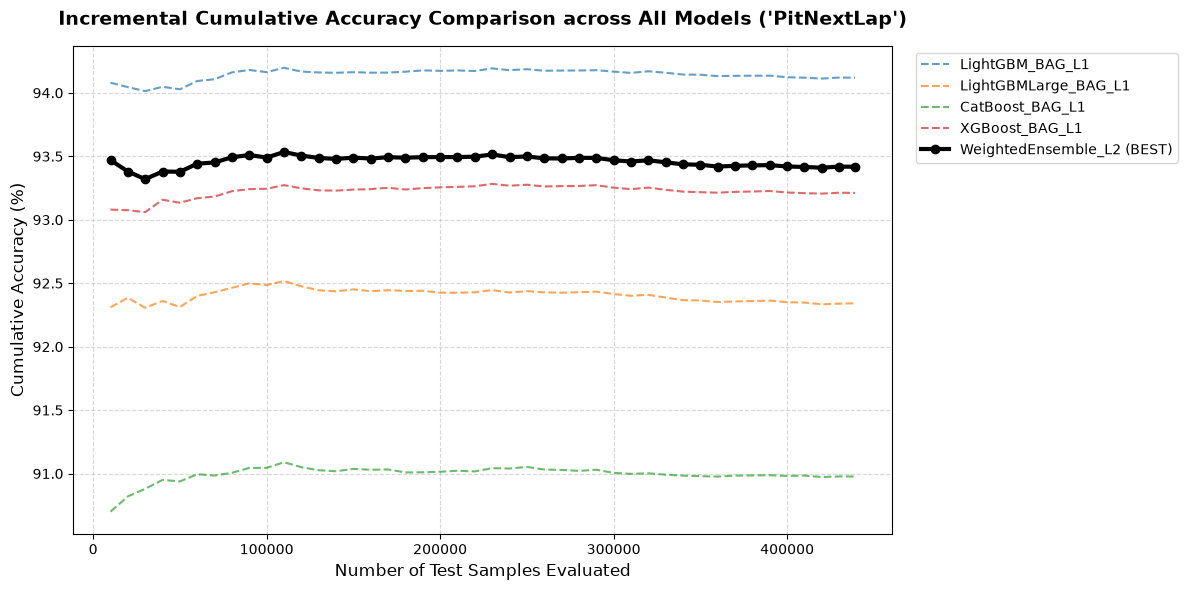


      FINAL ACCURACY RANKING SUMMARY
          Model Name  Final Accuracy (%)
     LightGBM_BAG_L1               94.12
 WeightedEnsemble_L2               93.42
      XGBoost_BAG_L1               93.21
LightGBMLarge_BAG_L1               92.34
     CatBoost_BAG_L1               90.98


In [18]:
df_all_model_results = evaluate_all_models_incremental(
    predictor=predictor_without_driver, df_test=df_train, target_col="PitNextLap", chunk_size=10000
)

# Model Accuracy Summary

## Summary

### When Driver Is Set to A

#### External

**Final Total Accuracy:** 93.01%
**Samples:** 101,371

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| LightGBM_BAG_L1      |              98.04 |
| WeightedEnsemble_L2  |              97.54 |
| XGBoost_BAG_L1       |              97.17 |
| LightGBMLarge_BAG_L1 |              96.84 |
| CatBoost_BAG_L1      |              93.24 |

#### Train

**Final Total Accuracy:** 91.79%
**Samples:** 439,140

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| LightGBM_BAG_L1      |              94.12 |
| WeightedEnsemble_L2  |              93.42 |
| XGBoost_BAG_L1       |              93.21 |
| LightGBMLarge_BAG_L1 |              92.34 |
| CatBoost_BAG_L1      |              90.98 |

---

## Without Driver

### Entire Train

**Final Total Accuracy:** 93.42%
**Samples:** 439,140

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| LightGBM_BAG_L1      |              94.12 |
| WeightedEnsemble_L2  |              93.42 |
| XGBoost_BAG_L1       |              93.21 |
| LightGBMLarge_BAG_L1 |              92.34 |
| CatBoost_BAG_L1      |              90.98 |

### External

**Final Total Accuracy:** 97.54%
**Samples:** 101,371

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| LightGBM_BAG_L1      |              98.04 |
| WeightedEnsemble_L2  |              97.54 |
| XGBoost_BAG_L1       |              97.17 |
| LightGBMLarge_BAG_L1 |              96.84 |
| CatBoost_BAG_L1      |              93.24 |

---

## With Driver

### External

**Final Total Accuracy:** 97.86%
**Samples:** 101,371

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| XGBoost_BAG_L1       |          **98.65** |
| WeightedEnsemble_L2  |              97.86 |
| LightGBMLarge_BAG_L1 |              97.04 |
| LightGBM_BAG_L1      |              96.88 |
| CatBoost_BAG_L1      |              96.46 |

### Entire Train

**Final Total Accuracy:** 92.97%
**Samples:** 439,140

| Model Name           | Final Accuracy (%) |
| -------------------- | -----------------: |
| LightGBM_BAG_L1      |          **94.12** |
| XGBoost_BAG_L1       |              93.67 |
| LightGBMLarge_BAG_L1 |              93.51 |
| WeightedEnsemble_L2  |              92.97 |
| CatBoost_BAG_L1      |              91.87 |
